Download Dataset from kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"venukaggle1","key":"4b81f85298c6c3e6b0ec2fb8271e0201"}'}

In [ ]:
!pip install kaggle

In [ ]:
#create a kaggle folder
!mkdir  ~/.kaggle


In [ ]:
#copy the kaggle.json to folder created
! cp kaggle.json ~/.kaggle/

In [ ]:
#permission for the json to act
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d patrickzel/flight-delay-and-cancellation-dataset-2019-2023

Dataset URL: https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023
License(s): other
 77% 107M/140M [00:00<00:00, 1.11GB/s]
100% 140M/140M [00:00<00:00, 636MB/s] 


In [ ]:
!unzip /content/flight-delay-and-cancellation-dataset-2019-2023.zip

Archive:  /content/flight-delay-and-cancellation-dataset-2019-2023.zip
  inflating: dictionary.html         
  inflating: flights_sample_3m.csv   


Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Flight delays and cancellations for January 2019 – August 2023


In [ ]:
df = pd.read_csv('/content/flights_sample_3m.csv')

In [ ]:
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

In [ ]:
df.AIRLINE.unique()

array(['United Air Lines Inc.', 'Delta Air Lines Inc.',
       'Spirit Air Lines', 'Southwest Airlines Co.',
       'American Airlines Inc.', 'Republic Airline',
       'Alaska Airlines Inc.', 'JetBlue Airways', 'PSA Airlines Inc.',
       'Allegiant Air', 'ExpressJet Airlines LLC d/b/a aha!',
       'SkyWest Airlines Inc.', 'Endeavor Air Inc.', 'Envoy Air',
       'Frontier Airlines Inc.', 'Mesa Airlines Inc.', 'Horizon Air',
       'Hawaiian Airlines Inc.'], dtype=object)

In [ ]:
df.DOT_CODE.unique()

array([19977, 19790, 20416, 19393, 19805, 20452, 19930, 20409, 20397,
       20368, 20366, 20304, 20363, 20398, 20436, 20378, 19687, 19690])

In [ ]:
df[['AIRLINE', 'AIRLINE_CODE', 'DOT_CODE','FL_NUMBER']].drop_duplicates()

,AIRLINE,AIRLINE_CODE,DOT_CODE,FL_NUMBER
0,United Air Lines Inc.,UA,19977,1562
1,Delta Air Lines Inc.,DL,19790,1149
2,United Air Lines Inc.,UA,19977,459
3,Delta Air Lines Inc.,DL,19790,2295
4,Spirit Air Lines,NK,20416,407
...,...,...,...,...
2986957,Frontier Airlines Inc.,F9,20436,1973
2987496,Allegiant Air,G4,20368,6245
2989975,Spirit Air Lines,NK,20416,2536
2999368,Frontier Airlines Inc.,F9,20436,705


Pre-Process

Handling missing values


In [ ]:
df.isna().sum()/df.shape[0]*100

,0
FL_DATE,0.000000
AIRLINE,0.000000
AIRLINE_DOT,0.000000
AIRLINE_CODE,0.000000
DOT_CODE,0.000000
FL_NUMBER,0.000000
ORIGIN,0.000000
ORIGIN_CITY,0.000000
DEST,0.000000
DEST_CITY,0.000000


Dataset datatypes

In [ ]:
print(df.dtypes)

FL_DATE                     object
AIRLINE                     object
AIRLINE_DOT                 object
AIRLINE_CODE                object
DOT_CODE                     int64
FL_NUMBER                    int64
ORIGIN                      object
ORIGIN_CITY                 object
DEST                        object
DEST_CITY                   object
CRS_DEP_TIME                 int64
DEP_TIME                   float64
DEP_DELAY                  float64
TAXI_OUT                   float64
WHEELS_OFF                 float64
WHEELS_ON                  float64
TAXI_IN                    float64
CRS_ARR_TIME                 int64
ARR_TIME                   float64
ARR_DELAY                  float64
CANCELLED                  float64
CANCELLATION_CODE           object
DIVERTED                   float64
CRS_ELAPSED_TIME           float64
ELAPSED_TIME               float64
AIR_TIME                   float64
DISTANCE                   float64
DELAY_DUE_CARRIER          float64
DELAY_DUE_WEATHER   

Converting column datatypes

In [ ]:
# these are columns where their datatypes has to be changed from int64, float64 to object
cols_to_obj = ['DOT_CODE', 'FL_NUMBER', 'CANCELLED', 'DIVERTED']

df[cols_to_obj] = df[cols_to_obj].astype('int64')
df[cols_to_obj] = df[cols_to_obj].astype('object')

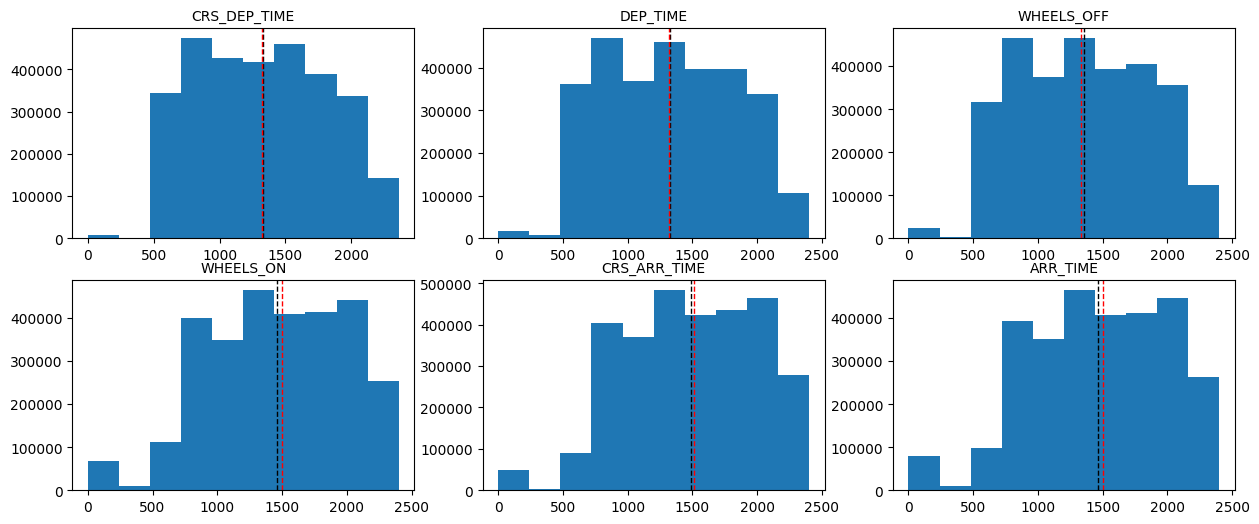

In [ ]:
# these are columns where their datatypes has to be changed from int64, float64 to datetime
cols_to_datetime = ['CRS_DEP_TIME', 'DEP_TIME', 'WHEELS_OFF', 'WHEELS_ON', 'CRS_ARR_TIME', 'ARR_TIME']

fig = plt.figure(figsize=(15,6))
rows, cols = 2,3

for i in range(1, len(cols_to_datetime)+1):
  fig.add_subplot(rows, cols, i)
  plt.hist(df[cols_to_datetime[i-1]])

  plt.title(cols_to_datetime[i-1],fontsize=10)

  #add horizontal average line
  plt.axvline(df[cols_to_datetime[i-1]].mean(),color='k', linestyle='dashed', linewidth=1)

  #add horizontal average line
  plt.axvline(df[cols_to_datetime[i-1]].median(),color='r', linestyle='dashed', linewidth=1)

In [ ]:
print(df[cols_to_datetime].isna().sum())

CRS_DEP_TIME        0
DEP_TIME        77615
WHEELS_OFF      78806
WHEELS_ON       79944
CRS_ARR_TIME        0
ARR_TIME        79942
dtype: int64


In [ ]:
print(f"Dataframe shape: {df.shape}")
df.dropna(subset=cols_to_datetime, inplace=True)
print(f"Dataframe shape after removing null values: {df.shape}")

Dataframe shape: (3000000, 32)
Dataframe shape after removing null values: (2920056, 32)


In [ ]:
# float to int datatype
df[cols_to_datetime] = df[cols_to_datetime].astype('int64')

In [ ]:
def format_time(time_str):
  return time_str[:-2] + ":" + time_str[-2:]

for col in cols_to_datetime:
  # Apply the function to the specified columns
  df[col] = df[col].astype(str).apply(format_time)

In [ ]:
  df[cols_to_datetime]

,CRS_DEP_TIME,DEP_TIME,WHEELS_OFF,WHEELS_ON,CRS_ARR_TIME,ARR_TIME
0,11:55,11:51,12:10,14:43,15:01,14:47
1,21:20,21:14,21:23,22:32,23:15,23:10
2,9:54,10:00,10:20,12:47,12:52,12:52
3,16:09,16:08,16:35,18:44,18:29,18:53
4,18:40,18:38,18:53,20:26,20:41,20:40
...,...,...,...,...,...,...
2999995,17:42,17:40,17:50,18:45,19:07,18:51
2999996,13:00,12:54,13:04,15:14,15:56,15:19
2999997,5:34,6:15,6:31,7:59,7:29,8:05
2999998,16:00,15:55,16:14,17:04,17:28,17:12


Filling missing time values with 0

In [ ]:
df.drop('CANCELLATION_CODE', axis=1, inplace=True)

In [ ]:
cols = ['ARR_DELAY', 'ELAPSED_TIME', 'AIR_TIME', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
        'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']

df[cols] = df[cols].fillna(0)

Working with time features

In [ ]:
# converting column to datetime
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
print(df['FL_DATE'].dtype)

# seperating year, month & day
df['FL_YEAR'] = df['FL_DATE'].dt.year
df['FL_MONTH'] = df['FL_DATE'].dt.month
df['FL_DAY'] = df['FL_DATE'].dt.day

# deleting date column
df.drop('FL_DATE', axis=1, inplace=True)

datetime64[ns]


TODO

EXCLUDE THE COLUMNS DUE_TO_DELAY_*

FEATURES WHICH NEED TO BE THERE ARE FLIGHT DETAILS Date, time, airline, origin/
destination

DISTANCE AND FLIGHT DURATION

Converting the time feature frmo HH:MM format to minutes

In [ ]:
def convert_time_to_minutes(time_str):
  try:
    hours, minutes = map(int, time_str.split(':'))
    return hours * 60 + minutes

  except ValueError:
    hours = 0
    minutes = int(time_str.replace(":", ""))
    return hours * 60 + minutes


for col in cols_to_datetime:
  df[col] = df[col].apply(convert_time_to_minutes)

In [ ]:
df[cols_to_datetime]

,CRS_DEP_TIME,DEP_TIME,WHEELS_OFF,WHEELS_ON,CRS_ARR_TIME,ARR_TIME
0,715,711,730,883,901,887
1,1280,1274,1283,1352,1395,1390
2,594,600,620,767,772,772
3,969,968,995,1124,1109,1133
4,1120,1118,1133,1226,1241,1240
...,...,...,...,...,...,...
2999995,1062,1060,1070,1125,1147,1131
2999996,780,774,784,914,956,919
2999997,334,375,391,479,449,485
2999998,960,955,974,1024,1048,1032


In [ ]:
# converting all the time features to int64
time_features = ['CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY',
                 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON','TAXI_IN',
                 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
                 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME']

df[time_features] = df[time_features].astype('int64')
print(df[time_features].dtypes)

CRS_DEP_TIME        int64
DEP_TIME            int64
DEP_DELAY           int64
TAXI_OUT            int64
WHEELS_OFF          int64
WHEELS_ON           int64
TAXI_IN             int64
CRS_ARR_TIME        int64
ARR_TIME            int64
ARR_DELAY           int64
CRS_ELAPSED_TIME    int64
ELAPSED_TIME        int64
AIR_TIME            int64
dtype: object


In [ ]:
df[['CANCELLED', 'DIVERTED']]

,CANCELLED,DIVERTED
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
2999995,0,0
2999996,0,0
2999997,0,0
2999998,0,0


In [ ]:
df[time_features]

,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME
0,715,711,-4,19,730,883,4,901,887,-14,186,176,153
1,1280,1274,-6,9,1283,1352,38,1395,1390,-5,235,236,189
2,594,600,6,20,620,767,5,772,772,0,118,112,87
3,969,968,-1,27,995,1124,9,1109,1133,24,260,285,249
4,1120,1118,-2,15,1133,1226,14,1241,1240,-1,181,182,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,1062,1060,-2,10,1070,1125,6,1147,1131,-16,85,71,55
2999996,780,774,-6,10,784,914,5,956,919,-37,176,145,130
2999997,334,375,41,16,391,479,6,449,485,36,55,50,28
2999998,960,955,-5,19,974,1024,8,1048,1032,-16,88,77,50


Creating our target column

In [ ]:
status = []

for value in df['ARR_DELAY']:
    if value <= 10:
        status.append(0)
    else:
        status.append(1)
df['FLIGHT_STATUS'] = status

Creating our target column

In [ ]:
df.columns

Index(['AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE', 'FL_NUMBER',
       'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CRS_DEP_TIME',
       'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON',
       'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED',
       'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
       'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT', 'FL_YEAR', 'FL_MONTH',
       'FL_DAY', 'FLIGHT_STATUS'],
      dtype='object')

In [ ]:
drop_cols = ['AIRLINE', 'AIRLINE_DOT', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN_CITY', 'DEST_CITY',
             'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']

df.drop(drop_cols, axis=1, inplace=True)

In [ ]:
df.head()

,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,...,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,FL_YEAR,FL_MONTH,FL_DAY,FLIGHT_STATUS
0,UA,FLL,EWR,715,711,-4,19,730,883,4,...,0,0,186,176,153,1065.0,2019,1,9,0
1,DL,MSP,SEA,1280,1274,-6,9,1283,1352,38,...,0,0,235,236,189,1399.0,2022,11,19,0
2,UA,DEN,MSP,594,600,6,20,620,767,5,...,0,0,118,112,87,680.0,2022,7,22,0
3,DL,MSP,SFO,969,968,-1,27,995,1124,9,...,0,0,260,285,249,1589.0,2023,3,6,1
4,NK,MCO,DFW,1120,1118,-2,15,1133,1226,14,...,0,0,181,182,153,985.0,2020,2,23,0


GNN for flight status

Creating a multigraph for flight status detection using flight delay data and applying a Graph Neural Network (GNN) on the edge list can be done in the following steps:

Preparing the flight delay data: Collect and organize the transaction data into a format that can be used to create the edges of the multigraph. For example, each flight journey could be represented as a tuple (node1, node2, attributes), where node1 and node2 represent the departure and arrival of the airport, and attributes is a dictionary containing properties such as the amount, timestamp, and transaction type.

Creating the multigraph: Use the flight delay data to create a multigraph using the NetworkX library. The add_edge() method can be used to add edges to the multigraph, where each edge represents a transaction.

Extract the edges list and their features: Use the edges() method of the multigraph to extract the edges list and their features, which will be used as input to the GNN.

Applying a GNN on the edge list: Use a GNN library such as PyTorch Geometric apply a GNN on the edge list. The GNN will learn representations of the edges in the multigraph and use them to classify the edges as fraudulent or non-fraudulent.

Evaluation: To evaluate the performance of the GNN, you can split the data into train and test sets, and use the test set to evaluate the accuracy, precision, recall, and F1-score of the model.

In [ ]:
df.to_csv('/content/drive/MyDrive/flightdelay_cleaned.csv', index=False)


OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Importing Data

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/flightdelay_cleaned.csv')
df_sample = df.sample(frac=0.01, random_state=42)

print(df_sample.shape)
print(df_sample.columns)


(29201, 23)
Index(['AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_TIME',
       'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN',
       'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'DIVERTED',
       'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'FL_YEAR',
       'FL_MONTH', 'FL_DAY', 'FLIGHT_STATUS'],
      dtype='object')


In [ ]:
raw = pd.read_csv('/content/drive/MyDrive/flights_sample_3m.csv')


In [ ]:
clean = pd.read_csv('/content/drive/MyDrive/flightdelay_cleaned.csv')


In [ ]:
extra_cols = raw[['DOT_CODE', 'FL_NUMBER']]


In [ ]:
clean['DOT_CODE'] = extra_cols['DOT_CODE']
clean['FL_NUMBER'] = extra_cols['FL_NUMBER']


In [ ]:
print(clean.shape)
print(clean.columns)


(2920056, 25)
Index(['AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_TIME',
       'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN',
       'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'DIVERTED',
       'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'FL_YEAR',
       'FL_MONTH', 'FL_DAY', 'FLIGHT_STATUS', 'DOT_CODE', 'FL_NUMBER'],
      dtype='object')


In [ ]:
clean.to_csv('/content/drive/MyDrive/flightdelay_cleaned_final.csv', index=False)


In [ ]:
import os

for f in os.listdir('/content/drive/MyDrive'):
    print(f)


Colab Notebooks
WORK SHEETS.docx
image003.png
IMG_2158.MOV
IMG_2692.MOV
IMG_2646.MOV
IMG_2167.MOV
IMG_2656.MOV
IMG_2304.MOV
IMG_2405 (1).MOV
IMG_2405.MOV
IMG_2168.MOV
IMG_2404 (1).MOV
IMG_2404.MOV
IMG_2157.MOV
IMG_2164.MOV
IMG_2698.MOV
IMG_2022.MOV
IMG_2023.MOV
IMG_2702.MOV
IMG_2645.MOV
IMG_2422 (1).MOV
IMG_2422.MOV
IMG_2700.MOV
IMG_2713.MOV
IMG_2014.MOV
IMG_2787.MOV
IMG_2174.MOV
gitanjali friends 2018-19.pdf
IMG_2693.MOV
IMG_2786.MOV
IMG_2031.MOV
IMG_2166.MOV
IMG_2370 (1).MOV
IMG_2370.MOV
IMG_2302 (1).MOV
IMG_2302.MOV
IMG_2655.MOV
IMG_2176.MOV
IMG_2699.MOV
IMG_2013.MOV
IMG_2763.MOV
IMG_2028.MOV
IMG_2035.MOV
IMG_2612.MOV
IMG_2177.MOV
IMG_2697.MOV
IMG_2012.MOV
IMG_2038.MOV
IMG_2672.MOV
IMG_2007.MOV
20200809_234245 (1).jpg
20200809_234245.jpg
Resume (2).gdoc
Resume (1).gdoc
Resume.gdoc
venu photo (2).jpg
image.jpg
WhatsApp Image 2022-10-30 at 10.41.45 PM.jpeg
WhatsApp Image 2023-09-25 at 8.00.44 PM.jpeg
sql certificate hackerrank.pdf
nptel java certificate.pdf
nptel java certificate.gdoc

Importing Data

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/flightdelay_cleaned_final.csv')


df_sample = df.sample(n=5000, random_state=42)  # Use 10% of the data

print(f"Number of rows: {df_sample.shape[0]} | Number of columns: {df_sample.shape[1]}")
print(f"\nColumns in the dataset: {df_sample.columns}")
print("\nTarget Variable: FLIGHT_STATUS")

Number of rows: 5000 | Number of columns: 25

Columns in the dataset: Index(['AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_TIME',
       'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN',
       'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'DIVERTED',
       'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'FL_YEAR',
       'FL_MONTH', 'FL_DAY', 'FLIGHT_STATUS', 'DOT_CODE', 'FL_NUMBER'],
      dtype='object')

Target Variable: FLIGHT_STATUS


In [ ]:
'''# Load dataset
df = pd.read_csv('/content/drive/MyDrive/flightdelay_cleaned_final.csv')

# Separate delayed and not-delayed flights
delayed = df[df['FLIGHT_STATUS'] == 1]
not_delayed = df[df['FLIGHT_STATUS'] == 0]

print("Delayed flights:", delayed.shape)
print("Not delayed flights:", not_delayed.shape)

# Pick equal number of samples from each class
num_samples = 2500  # half of 5000

delayed_sample = delayed.sample(n=num_samples, random_state=42)
not_delayed_sample = not_delayed.sample(n=num_samples, random_state=42)

# Combine to make balanced dataset
df_sample = pd.concat([delayed_sample, not_delayed_sample])

# Shuffle the final dataset
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset shape: {df_sample.shape}")
print(df_sample['FLIGHT_STATUS'].value_counts())
'''

'# Load dataset\ndf = pd.read_csv(\'/content/drive/MyDrive/flightdelay_cleaned_final.csv\')\n\n# Separate delayed and not-delayed flights\ndelayed = df[df[\'FLIGHT_STATUS\'] == 1]\nnot_delayed = df[df[\'FLIGHT_STATUS\'] == 0]\n\nprint("Delayed flights:", delayed.shape)\nprint("Not delayed flights:", not_delayed.shape)\n\n# Pick equal number of samples from each class\nnum_samples = 2500  # half of 5000\n\ndelayed_sample = delayed.sample(n=num_samples, random_state=42)\nnot_delayed_sample = not_delayed.sample(n=num_samples, random_state=42)\n\n# Combine to make balanced dataset\ndf_sample = pd.concat([delayed_sample, not_delayed_sample])\n\n# Shuffle the final dataset\ndf_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)\n\nprint(f"\nBalanced dataset shape: {df_sample.shape}")\nprint(df_sample[\'FLIGHT_STATUS\'].value_counts())\n'

Train-Test split

In [ ]:
from sklearn.model_selection import train_test_split

# Define features and target
features = df_sample.drop(['FLIGHT_STATUS'], axis=1)
target = df_sample['FLIGHT_STATUS']  # Assuming this is your target column

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Reconstruct the training dataframe for node and edge creation
train_df = X_train.copy()
train_df['FLIGHT_STATUS'] = y_train

Data Analysis

In [ ]:
for i in ['FL_YEAR','FL_MONTH', 'FL_DAY']:
  print(i)
  print(set(df_sample[i].unique()))
  print("\n")

FL_YEAR
{np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)}


FL_MONTH
{np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)}


FL_DAY
{np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)}




Group by Airline + Origin  
Count how many flights exist in each group

In [ ]:
df_sample.groupby(['AIRLINE_CODE','ORIGIN'])['DEST'].size()

AIRLINE_CODE  ORIGIN
9E            AEX        3
              AGS        2
              ALB        1
              ATL       23
              BGR        1
                        ..
YX            SAV        3
              SDF        4
              SRQ        2
              STL        1
              TVC        1
Name: DEST, Length: 998, dtype: int64

Which airline flies the most flights between which origin and destination.

In [ ]:

df_sample.groupby(['AIRLINE_CODE','ORIGIN','DEST']).size().sort_values(ascending=False)

AIRLINE_CODE  ORIGIN  DEST
DL            ATL     MCO     8
              MSY     ATL     7
WN            BWI     TPA     7
B6            JFK     MCO     7
DL            LAX     ATL     7
                             ..
9E            ATL     HOU     1
                      GNV     1
                      DSM     1
                      CID     1
                      BMI     1
Length: 3395, dtype: int64

For every airline + origin airport + destination airport route,
count how many flights were DELAYED.

In [ ]:
df_sample.groupby(['AIRLINE_CODE','ORIGIN','DEST'])['FLIGHT_STATUS'].sum().sort_values(ascending=False)

AIRLINE_CODE  ORIGIN  DEST
B6            DCA     BOS     5
              JFK     MCO     4
WN            BWI     TPA     4
              AUS     DAL     3
DL            ATL     LAX     3
                             ..
YX            SAV     PHL     0
                      DCA     0
              SAT     ORD     0
              RSW     LGA     0
              ROC     LGA     0
Name: FLIGHT_STATUS, Length: 3395, dtype: int64

“Which airline has the most number of delayed flights?”

In [ ]:
df_sample.groupby(['AIRLINE_CODE'])['FLIGHT_STATUS'].sum().sort_values(ascending=False)

,FLIGHT_STATUS
AIRLINE_CODE,
WN,203
AA,158
DL,115
OO,104
UA,97
B6,66
OH,45
YX,43
NK,40


“On each day, for each origin–destination route, how many flights were delayed?
And then show the worst delay days first.”

In [ ]:
df_sample.groupby(['FL_YEAR', 'FL_MONTH', 'FL_DAY', 'ORIGIN', 'DEST'])[['FLIGHT_STATUS']].sum().sort_values(by='FLIGHT_STATUS',ascending=False)

FLIGHT_STATUS
FL_YEAR FL_MONTH FL_DAY ORIGIN DEST               
2023    8        27     ORD    DEN               1
                        HOU    LAX               1
                 26     TVC    MSP               1
2019    1        10     ATL    DCA               1
                 9      HOU    CRP               1
...                                            ...
2023    8        28     DCA    MVY               0
                        CLT    HPN               0
                        BWI    HOU               0
                        ATW    ORD               0
                 27     PHX    IND               0

[4996 rows x 1 columns]

It arranges your entire dataset in proper date order — from oldest flight to newest flight.

In [ ]:
df_sample = df_sample.sort_values(['FL_YEAR', 'FL_MONTH', 'FL_DAY'], ascending=True)

Counter: To count the number (like: How many times a certain route appears,How many delayed flights, Node/edge frequencies for GNN)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F

Creating a directed graph. Nodes represent the flight route and edges represent the routes. There can be thousands of similar route, so we are combining airline code, source, destination to get unique routes. Each unique route is an edge. Even if we have same repeated edges then we ignore them because these edges and nodes are already added to the graph.

In [ ]:
G = nx.DiGraph()

# Create a set to store unique flight identifiers
unique_flights = set()

# Create nodes for unique flights
for index, row in df_sample.iterrows():
    # Create a unique identifier for each flight based on relevant columns
    flight_id = f"{row['AIRLINE_CODE']}_{row['ORIGIN']}_{row['DEST']}"

    # Only add the node if this flight_id is not already in the set
    if flight_id not in unique_flights:
        G.add_node(flight_id,
                   airline=row['AIRLINE_CODE'],
                   origin=row['ORIGIN'],
                   destination=row['DEST'],
                   crs_dep_time=row['CRS_DEP_TIME'],
                   dep_time=row['DEP_TIME'],
                   arr_time=row['ARR_TIME'],
                   crs_arr_time=row['CRS_ARR_TIME'],
                   dep_delay=row['DEP_DELAY'],
                   flight_status=row['FLIGHT_STATUS'])

        # Add the flight_id to the set of unique flights
        unique_flights.add(flight_id)

# Print graph information
print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph created with 3395 nodes and 0 edges.


1. Each flight becomes a node
2. Flights at the same origin airport are checked
3. If two flights leave close in time, we connect them(we put a threshold time)
What does this connection mean?(It means:  These two flights may affect each other.)



---



In [ ]:
df_sample['flight_id'] = df_sample['AIRLINE_CODE'] + "_" + df_sample['FL_NUMBER'].astype(str) + "_" + df_sample['FL_YEAR'].astype(str)+ "_" + df_sample['FL_MONTH'].astype(str)+ "_" + df_sample['FL_DAY'].astype(str)

# Define the time threshold for temporal proximity (e.g., 30 minutes)
time_threshold = 30

# Create edges based on temporal proximity at the same origin airport
for origin, group in df_sample.groupby('ORIGIN'):
    # Sort flights by departure time within each origin
    group = group.sort_values(by='CRS_DEP_TIME')

    # Iterate through each pair of flights at the same origin
    for i in range(len(group)):
        for j in range(i + 1, len(group)):
            # Get the departure time difference
            time_diff = abs(group.iloc[i]['CRS_DEP_TIME'] - group.iloc[j]['CRS_DEP_TIME'])

            # If the time difference is within the threshold, create an edge
            if time_diff <= time_threshold:
                G.add_edge(group.iloc[i]['flight_id'], group.iloc[j]['flight_id'])

# Print graph information
print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph created with 7659 nodes and 16234 edges.


STEP 1 — Make each flight a node
ONE NODE = ONE FLIGHT on ONE DAY

STEP 2 — Group flights by same ORIGIN airport

STEP 3 — Sort flights by time at that airport

STEP 4 — Connect flights close in time (within 30 minutes)

STEP 5 — Group flights by same AIRLINE & same DAY

STEP 6 — Connect ALL flights from same airline on same day

In [ ]:
# Create edges based on same AIRLINE_CODE and same FL_DATE
for airline, group in df_sample.groupby(['AIRLINE_CODE', 'FL_MONTH', 'FL_DAY']):
    flight_ids = group['flight_id'].tolist()

    # Connect every pair of flights from the same airline on the same day
    for i in range(len(flight_ids)):
        for j in range(i + 1, len(flight_ids)):
            G.add_edge(flight_ids[i], flight_ids[j])

# Print graph information
print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph created with 8096 nodes and 19798 edges.


Node = ONE FLIGHT

Edge = a connection between two flights that fly on the SAME ROUTE

STEP 1 — Group flights by ORIGIN and DEST

STEP 2 — Take all flight IDs in that group

STEP 3 — Connect EVERY flight in the group with an edge


In [ ]:
# Create edges based on Origin-Destination pairs
# Group flights by ORIGIN and DEST
for od_pair, group in df_sample.groupby(['ORIGIN', 'DEST']):
    flight_ids = group['flight_id'].tolist()

    # Connect every pair of flights flying between the same ORIGIN and DEST
    for i in range(len(flight_ids)):
        for j in range(i + 1, len(flight_ids)):
            G.add_edge(flight_ids[i], flight_ids[j])

# Print graph information
print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph created with 8245 nodes and 24607 edges.


Each node = ONE FLIGHT

Edge = two flights BOTH had big delays (greater than 30 minutes)

STEP 1 — Choose a “big delay” threshold

STEP 2 — Pick only the heavily delayed flights

STEP 3 — Get their flight IDs

STEP 4 — Connect ALL delayed flights with each other

In [ ]:
# Threshold for delay (in minutes)
delay_threshold = 30

# Create edges based on similar delays
# Filter flights that have DEP_DELAY or ARR_DELAY greater than the threshold
delayed_flights = df_sample[(df_sample['DEP_DELAY'] > delay_threshold) | (df_sample['ARR_DELAY'] > delay_threshold)]

# Create edges between all flights with delays greater than the threshold
flight_ids = delayed_flights['flight_id'].tolist()

# Create edges between all flights with similar delays
for i in range(len(flight_ids)):
    for j in range(i + 1, len(flight_ids)):
        G.add_edge(flight_ids[i], flight_ids[j], relationship="similar_delay")

# Print graph information
print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph created with 8260 nodes and 259866 edges.


ONE graph, MANY relationships inside it.

This single node may have edges coming from:

✔️ Same origin airport (JFK)

✔️ Same airline (American Airlines)

✔️ Same route (JFK → LAX)

✔️ Similar delay pattern (>30 mins)

✔️ Close departure time with another flight

This SAME NODE gets multiple connections from different rules.

NOT multiple graphs.

STEP 1 — Convert all nodes into a list

STEP 2 — Convert all edges into a list

STEP 3 — Use pickle to save EVERYTHING into a file

You are saving BOTH into a file called gnn_data.pkl

In [ ]:
import networkx as nx
import pickle

# Assume G is your NetworkX graph object
nodes = list(G.nodes(data=True))
edges = list(G.edges(data=True))

# Save the nodes and edges using pickle
with open('gnn_data.pkl', 'wb') as f:
    pickle.dump({'nodes': nodes, 'edges': edges}, f)

In [ ]:
import os
os.listdir('/content')


['.config',
 'kaggle.json',
 'dictionary.html',
 'flight-delay-and-cancellation-dataset-2019-2023.zip',
 'flights_sample_3m.csv',
 'gnn_data.pkl',
 'drive',
 'sample_data']

In [ ]:
import pickle

with open('/content/gnn_data.pkl', 'rb') as f:
    data = pickle.load(f)

print(type(data))


<class 'dict'>


In [ ]:
loaded_nodes = data['nodes']
loaded_edges = data['edges']

STEP 1 — We make empty lists

STEP 2 — For every flight (node), we pick out its information

STEP 3 — Convert text to numbers

STEP 4 — Make delay and time smaller according to scale

STEP 5 — Combine everything into ONE table

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler #convert text to number, convert big number to small number

# Lists to store extracted attributes
airlines = []
origins = []
destinations = []
dep_delays = []
crs_dep_times = []

# Default values for missing data
default_airline = 'UNKNOWN'
default_origin = 'UNKNOWN'
default_destination = 'UNKNOWN'
default_dep_delay = 0  # e.g., no delay
default_crs_dep_time = 0  # e.g., midnight

# Extract features from loaded_nodes
for node_id, attrs in loaded_nodes:
    # Handle missing attributes by using default values
    airline = attrs.get('airline', default_airline)
    origin = attrs.get('origin', default_origin)
    destination = attrs.get('destination', default_destination)
    dep_delay = attrs.get('dep_delay', default_dep_delay)
    crs_dep_time = attrs.get('crs_dep_time', default_crs_dep_time)

    airlines.append(airline)
    origins.append(origin)
    destinations.append(destination)
    dep_delays.append(dep_delay)
    crs_dep_times.append(crs_dep_time)

# Encode categorical features (airline, origin, destination)
label_encoder_airline = LabelEncoder()
label_encoder_origin = LabelEncoder()
label_encoder_destination = LabelEncoder()

encoded_airlines = label_encoder_airline.fit_transform(airlines)
encoded_origins = label_encoder_origin.fit_transform(origins)
encoded_destinations = label_encoder_destination.fit_transform(destinations)

# Normalize numerical features (dep_delay, crs_dep_time)
scaler = StandardScaler()
scaled_dep_delays = scaler.fit_transform(np.array(dep_delays).reshape(-1, 1)).flatten()
scaled_crs_dep_times = scaler.fit_transform(np.array(crs_dep_times).reshape(-1, 1)).flatten()

# Combine the encoded and scaled features into a feature matrix
node_features = np.vstack([encoded_airlines, encoded_origins, encoded_destinations, scaled_dep_delays, scaled_crs_dep_times]).T

# Display the result (for verification)
print("Node features matrix:")
print(node_features)

Node features matrix:
[[ 1.80000000e+01  1.83000000e+02  8.00000000e+01  1.60522203e+00
   1.79818725e+00]
 [ 1.00000000e+00  3.10000000e+01  5.00000000e+01 -1.74278684e-01
   1.49914910e+00]
 [ 1.20000000e+01  1.66000000e+02  1.20000000e+01 -3.22570410e-01
   7.29672002e-02]
 ...
 [ 1.50000000e+01  2.58000000e+02  2.50000000e+02 -1.37205752e-01
  -7.55138422e-01]
 [ 1.50000000e+01  2.58000000e+02  2.50000000e+02 -1.37205752e-01
  -7.55138422e-01]
 [ 1.50000000e+01  2.58000000e+02  2.50000000e+02 -1.37205752e-01
  -7.55138422e-01]]


In [ ]:
from sklearn.model_selection import train_test_split

# Create a train-test split
train_nodes, test_nodes = train_test_split(loaded_nodes, test_size=0.2, random_state=42)

In [ ]:
# extracting features for train/test nodes after splitting
train_node_features = np.array([node_features[i] for i, (node_id, attrs) in enumerate(loaded_nodes) if (node_id, attrs) in train_nodes])
test_node_features = np.array([node_features[i] for i, (node_id, attrs) in enumerate(loaded_nodes) if (node_id, attrs) in test_nodes])

In [ ]:
print(f"Train shape: {len(train_nodes)} | Test shape: {len(test_nodes)}")
print(f"Train node features: {len(train_node_features)} | Test node features: {len(test_node_features)}")

Train shape: 6608 | Test shape: 1652
Train node features: 6608 | Test node features: 1652


In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.8 MB/s eta 0:00:00


STEP 1 — Give every flight a number

STEP 2 — Convert edges to numbers

STEP 3 — Put all these edges into a PyTorch tensor

STEP 4 — Convert node features to tensor

STEP 5 — Create the final graph object



In [ ]:
import torch
from torch_geometric.data import Data

# Create a dictionary of node indices for quick lookup
node_index_map = {node[0]: idx for idx, node in enumerate(loaded_nodes)}

# Filter out edges where either node is missing from the nodes list
filtered_edges = [
    (node_index_map[edge[0]], node_index_map[edge[1]])
    for edge in loaded_edges
    if edge[0] in node_index_map and edge[1] in node_index_map
]

# Convert to PyTorch tensor
edge_index = torch.tensor(filtered_edges, dtype=torch.long).t().contiguous()

# Assuming node_features is available and converted to tensor as before
x = torch.tensor(node_features, dtype=torch.float)

# Create PyTorch Geometric data object
data = Data(x=x, edge_index=edge_index)

# Check the graph data structure
print(data)

Data(x=[8260, 5], edge_index=[2, 259866])


STEP 1 — Import functions

STEP 2 — Define the GCN model

STEP 3 — Initialize the model (the layers)

STEP 4 — Forward pass (how model works)

STEP 5 — Initialize the model



In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Initialize the model
model = GCN(num_node_features=x.shape[1], num_classes=2)  # Assuming binary classification
print(model)

GCN(
  (conv1): GCNConv(5, 16)
  (conv2): GCNConv(16, 2)
)


What are we doing here?

We are creating masks that tell the GNN:

Which flights to train on

Which flights to test on

STEP 1 — Get list of ALL node IDs

STEP 2 — Extract IDs for training and testing

STEP 3 — Create mask lists full of False

STEP 4 — Mark training nodes as True

STEP 5 — Mark test nodes as True

In [ ]:
# Assuming loaded_nodes contains all your nodes and train_nodes, test_nodes are the split sets
node_ids = [node[0] for node in loaded_nodes]  # Extract node names
train_node_ids = [node[0] for node in train_nodes]
test_node_ids = [node[0] for node in test_nodes]

# Initialize masks as all False
train_mask = torch.zeros(len(loaded_nodes), dtype=torch.bool)
test_mask = torch.zeros(len(loaded_nodes), dtype=torch.bool)

# Set True for training nodes
for node_id in train_node_ids:
    idx = node_ids.index(node_id)
    train_mask[idx] = True

# Set True for test nodes
for node_id in test_node_ids:
    idx = node_ids.index(node_id)
    test_mask[idx] = True

# Now you can use train_mask and test_mask in your training loop
print("Training Mask:", train_mask)
print("Test Mask:", test_mask)

Training Mask: tensor([ True,  True,  True,  ...,  True, False,  True])
Test Mask: tensor([False, False, False,  ..., False,  True, False])


In [ ]:
labels = []
for node in loaded_nodes:
    if 'flight_status' in node[1]:
        labels.append(node[1]['flight_status'])
    else:
        labels.append(0)  # Assign a default class (e.g., 0) for nodes without a flight_status

data.y = torch.tensor(labels, dtype=torch.long)

In [ ]:
print(data)  # Check if data contains x, edge_index, and y properly

Data(x=[8260, 5], edge_index=[2, 259866], y=[8260])


In [ ]:
import torch.optim as optim

# Use cross-entropy loss and Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = torch.nn.CrossEntropyLoss()

# Assume train_mask and test_mask separate training and test nodes (if applicable)
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = loss_fn(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Training loop
for epoch in range(201):
    loss = train()
    print(f'Epoch {epoch}, Loss: {loss}')

Epoch 0, Loss: 3.4912736415863037
Epoch 1, Loss: 2.7432000637054443
Epoch 2, Loss: 2.151719570159912
Epoch 3, Loss: 1.7554278373718262
Epoch 4, Loss: 1.414886713027954
Epoch 5, Loss: 1.098818302154541
Epoch 6, Loss: 0.8979336023330688
Epoch 7, Loss: 0.7426661252975464
Epoch 8, Loss: 0.6558504104614258
Epoch 9, Loss: 0.6550363898277283
Epoch 10, Loss: 0.6583269834518433
Epoch 11, Loss: 0.5967020988464355
Epoch 12, Loss: 0.4856453239917755
Epoch 13, Loss: 0.3935975134372711
Epoch 14, Loss: 0.46230727434158325
Epoch 15, Loss: 0.37874966859817505
Epoch 16, Loss: 0.38469797372817993
Epoch 17, Loss: 0.4181256592273712
Epoch 18, Loss: 0.41026246547698975
Epoch 19, Loss: 0.37233930826187134
Epoch 20, Loss: 0.3915445804595947
Epoch 21, Loss: 0.3671131730079651
Epoch 22, Loss: 0.3465571701526642
Epoch 23, Loss: 0.35227304697036743
Epoch 24, Loss: 0.3365912139415741
Epoch 25, Loss: 0.3075424134731293
Epoch 26, Loss: 0.29981574416160583
Epoch 27, Loss: 0.2989285886287689
Epoch 28, Loss: 0.27458757

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Ensure the model is in evaluation mode
model.eval()

# Forward pass (only pass in node features and edges)
out = model(data)

# Get predictions by taking the argmax of the model's output
pred = out.argmax(dim=1)

In [ ]:
'''from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming pred and true_labels are the predicted and true labels
true_labels = data.y
pred_labels = pred

precision = precision_score(true_labels.cpu(), pred_labels.cpu(), average='weighted')
recall = recall_score(true_labels.cpu(), pred_labels.cpu(), average='weighted')
f1 = f1_score(true_labels.cpu(), pred_labels.cpu(), average='weighted'  )

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")'''


'from sklearn.metrics import precision_score, recall_score, f1_score\n\n# Assuming pred and true_labels are the predicted and true labels\ntrue_labels = data.y\npred_labels = pred\n\nprecision = precision_score(true_labels.cpu(), pred_labels.cpu(), average=\'weighted\')\nrecall = recall_score(true_labels.cpu(), pred_labels.cpu(), average=\'weighted\')\nf1 = f1_score(true_labels.cpu(), pred_labels.cpu(), average=\'weighted\'  )\n\nprint(f"Precision: {precision}")\nprint(f"Recall: {recall}")\nprint(f"F1 Score: {f1}")'

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming pred and true_labels are the predicted and true labels
true_labels = data.y
pred_labels = pred

precision = precision_score(true_labels.cpu(), pred_labels.cpu(), average='weighted')
recall = recall_score(true_labels.cpu(), pred_labels.cpu(), average='weighted')
f1 = f1_score(true_labels.cpu(), pred_labels.cpu(), average='weighted'  )

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Precision: 0.9439175401737764
Recall: 0.9483050847457627
F1 Score: 0.9443648472692415


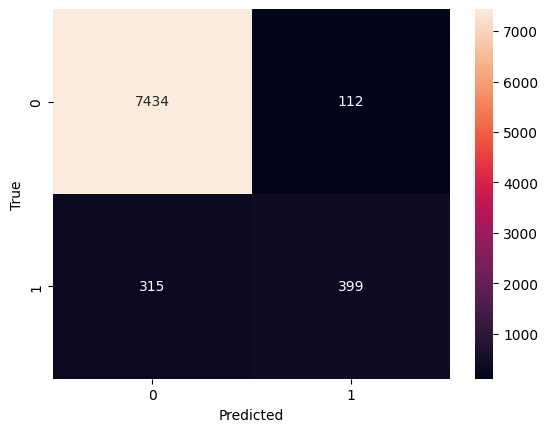

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(true_labels.cpu(), pred_labels.cpu())

# Plot confusion matrix using seaborn
sns.heatmap(conf_matrix, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()
test_loss = loss_fn(out, data.y)
print(f"Test Loss: {test_loss}")

Test Loss: 0.15295833349227905


In [ ]:
# Save the model's state_dict to a .pth file
torch.save(model.state_dict(), 'model.pth')

In [ ]:
# Assume you have the same model architecture
model = GCN(num_node_features=data.num_node_features, num_classes=2)

# Load the model's state_dict
model.load_state_dict(torch.load('/content/model.pth'))

# Put the model into evaluation mode (especially useful if you are doing inference)
model.eval()

# Forward pass (only pass in node features and edges)
out = model(data)

# Get predictions by taking the argmax of the model's output
pred = out.argmax(dim=1)

# Assuming pred and true_labels are the predicted and true labels
true_labels = data.y
pred_labels = pred

precision = precision_score(true_labels.cpu(), pred_labels.cpu(), average='weighted')
recall = recall_score(true_labels.cpu(), pred_labels.cpu(), average='weighted')
f1 = f1_score(true_labels.cpu(), pred_labels.cpu(), average='weighted')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Precision: 0.9439175401737764
Recall: 0.9483050847457627
F1 Score: 0.9443648472692415


Testing


In [ ]:
def test():
    model.eval()
    out = model(data)
    pred = out.argmax(dim=1)   # predicted class (0 or 1)

    correct = pred[test_mask] == data.y[test_mask]
    acc = int(correct.sum()) / int(test_mask.sum())

    return acc, pred

test_acc, predictions = test()
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 95.16%


In [ ]:
print("\nFlight Predictions on Test Data:\n")
for i, (node_id, attrs) in enumerate(loaded_nodes):
    if test_mask[i]:
        print(node_id, "=> Prediction:", predictions[i].item())



Flight Predictions on Test Data:

WN_DAL_AUS => Prediction: 0
NK_FLL_ORD => Prediction: 0
OO_FAT_LAX => Prediction: 0
NK_DFW_DEN => Prediction: 0
AA_MIA_MSY => Prediction: 0
DL_ATL_DCA => Prediction: 1
DL_HOU_ATL => Prediction: 0
YX_ORD_CLT => Prediction: 0
AA_FLL_CLT => Prediction: 0
UA_BNA_IAH => Prediction: 0
OO_ATL_TLH => Prediction: 0
OO_LAX_ASE => Prediction: 1
WN_FLL_BNA => Prediction: 0
B6_PHL_FLL => Prediction: 0
HA_LIH_HNL => Prediction: 0
MQ_LGA_RIC => Prediction: 0
UA_SFO_PDX => Prediction: 0
WN_FLL_BUF => Prediction: 0
NK_MCO_EWR => Prediction: 0
9E_TYS_DTW => Prediction: 0
AA_DFW_SEA => Prediction: 1
WN_BWI_STL => Prediction: 0
WN_DEN_ATL => Prediction: 0
AA_BOS_LGA => Prediction: 0
YV_DFW_HOU => Prediction: 1
WN_MKE_DAL => Prediction: 0
F9_RSW_DEN => Prediction: 0
WN_ABQ_LAS => Prediction: 0
UA_SFO_ONT => Prediction: 0
DL_ATL_GSP => Prediction: 0
DL_CAE_ATL => Prediction: 0
EV_IAH_LIT => Prediction: 0
WN_ONT_PHX => Prediction: 0
DL_ATL_LIT => Prediction: 0
AA_DFW_LAX =>

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def test():
    model.eval()
    out = model(data)                     # Model output for ALL nodes
    pred = out.argmax(dim=1)              # Predicted class (0 or 1)

    # Only evaluate nodes in test_mask
    test_preds = pred[test_mask].cpu().numpy()
    test_labels = data.y[test_mask].cpu().numpy()

    # Calculate metrics
    acc = accuracy_score(test_labels, test_preds)
    precision = precision_score(test_labels, test_preds, zero_division=0)
    recall = recall_score(test_labels, test_preds, zero_division=0)
    f1 = f1_score(test_labels, test_preds, zero_division=0)

    return acc, precision, recall, f1, pred

acc, precision, recall, f1, predictions = test()

print(f"\nTest Accuracy:  {acc*100:.2f}%")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1 Score:       {f1:.4f}")



Test Accuracy:  95.16%
Precision:      0.8037
Recall:         0.5931
F1 Score:       0.6825
